# (7065) Fredschaaf — локальная редукция серии

Обрабатываем все 98 реальных R-кадров 2025-09-03. Сначала строим усреднённую систему локальных звёзд, затем делаем независимые стеки по 10 кадров и измеряем центр астероида двумерным гауссовым профилем.

In [8]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.stats import sigma_clip, sigma_clipped_stats
from astropy.time import Time, TimeDelta
from astropy.wcs import FITSFixedWarning, WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from photutils.centroids import centroid_2dg
from scipy.ndimage import shift as image_shift
from scipy.optimize import curve_fit

warnings.simplefilter("ignore", FITSFixedWarning)

## 1. Параметры

Координаты и скорости получены из JPL Horizons для (7065) Fredschaaf, обсерватории 217 и момента 2025-09-03 21:20 UTC. Эфемерида задаёт только область поиска и сдвиги при сложении.

In [9]:
ROOT = Path.cwd()
SERIES_DIR = ROOT / "Fredschaaf" / "20250903"
FRAME_PATHS = sorted(SERIES_DIR.glob("7065_R_4_*_wcs.fits"))
CATALOG_PATH = SERIES_DIR / "gaia_dr3_field.csv"
LOCAL_RADIUS_PX = 450
STAR_RMS_LIMIT_MAS = 130
GROUP_SIZE = 10
STAR_HALF_BOX = 10
STACK_HALF_SIZE = 20

HORIZONS_TIME = Time("2025-09-03T21:20:00", scale="utc")
HORIZONS_RA_DEG = 43.48787
HORIZONS_DEC_DEG = 15.44055
RA_RATE_ARCSEC_H = 10.48579
DEC_RATE_ARCSEC_H = -3.52047

gaia_catalog = pd.read_csv(CATALOG_PATH)
gaia_catalog = gaia_catalog.dropna(subset=["ra", "dec", "pmra", "pmdec", "ref_epoch"])
gaia_catalog = gaia_catalog[gaia_catalog.phot_g_mean_mag.between(5.0, 16.5)].copy()
print(f"Кадров: {len(FRAME_PATHS)}")
print(f"Gaia-звёзд в каталоге: {len(gaia_catalog)}")

Кадров: 98
Gaia-звёзд в каталоге: 178


## 2. Вспомогательные функции

In [10]:
def read_frame(path):
    with fits.open(path, memmap=False) as hdul:
        return hdul[0].data.astype(float), hdul[0].header.copy()


def middle_time(header):
    start = Time(header["DATE-OBS"], format="isot", scale="utc")
    return start + TimeDelta(float(header["EXPTIME"]) / 2, format="sec")


def asteroid_coordinates(time):
    hours = (time - HORIZONS_TIME).to_value("hour")
    ra = HORIZONS_RA_DEG + RA_RATE_ARCSEC_H * hours / (3600 * np.cos(np.deg2rad(HORIZONS_DEC_DEG)))
    dec = HORIZONS_DEC_DEG + DEC_RATE_ARCSEC_H * hours / 3600
    return ra, dec


def gaia_at_time(catalog, time):
    result = catalog.copy()
    years = time.jyear - result.ref_epoch.to_numpy(float)
    result["ra_epoch"] = result.ra + result.pmra * years / (3_600_000 * np.cos(np.deg2rad(result.dec)))
    result["dec_epoch"] = result.dec + result.pmdec * years / 3_600_000
    return result


def tangent_plane(ra_deg, dec_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(HORIZONS_RA_DEG), np.deg2rad(HORIZONS_DEC_DEG)
    denominator = np.sin(dec) * np.sin(dec0) + np.cos(dec) * np.cos(dec0) * np.cos(ra - ra0)
    xi = np.cos(dec) * np.sin(ra - ra0) / denominator
    eta = (np.sin(dec) * np.cos(dec0) - np.cos(dec) * np.sin(dec0) * np.cos(ra - ra0)) / denominator
    return np.column_stack([np.rad2deg(xi), np.rad2deg(eta)])


def measure_star(image, x, y, half_box=STAR_HALF_BOX):
    ix, iy = int(round(x)), int(round(y))
    cutout = image[iy-half_box:iy+half_box+1, ix-half_box:ix+half_box+1]
    if cutout.shape != (2 * half_box + 1, 2 * half_box + 1):
        return np.nan, np.nan
    try:
        cx, cy = centroid_2dg(cutout - np.nanmedian(cutout))
    except Exception:
        return np.nan, np.nan
    if not (np.isfinite(cx) and np.isfinite(cy) and 0 < cx < 2 * half_box and 0 < cy < 2 * half_box):
        return np.nan, np.nan
    return ix - half_box + cx, iy - half_box + cy

## 3. Измерьте одинаковые локальные звёзды на всех кадрах

Список `source_id` выбирается на первом кадре. Затем центры этих же звёзд измеряются на каждом из 98 кадров.

In [11]:
first_image, first_header = read_frame(FRAME_PATHS[0])
first_time = middle_time(first_header)
first_wcs = WCS(first_header)
first_catalog = gaia_at_time(gaia_catalog, first_time)
first_xy = first_wcs.all_world2pix(first_catalog[["ra_epoch", "dec_epoch"]].to_numpy(), 0)
asteroid_ra, asteroid_dec = asteroid_coordinates(first_time)
asteroid_xy = first_wcs.all_world2pix([[asteroid_ra, asteroid_dec]], 0)[0]
distance = np.hypot(first_xy[:, 0] - asteroid_xy[0], first_xy[:, 1] - asteroid_xy[1])
local_ids = first_catalog.loc[distance <= LOCAL_RADIUS_PX, "source_id"].astype("int64").tolist()

measurement_rows = []
frame_rows = []
for frame_number, path in enumerate(FRAME_PATHS):
    image, header = read_frame(path)
    time = middle_time(header)
    wcs = WCS(header)
    catalog = gaia_at_time(gaia_catalog, time)
    catalog = catalog[catalog.source_id.isin(local_ids)].copy()
    predicted_xy = wcs.all_world2pix(catalog[["ra_epoch", "dec_epoch"]].to_numpy(), 0)

    for star, (x_wcs, y_wcs) in zip(catalog.itertuples(), predicted_xy):
        x, y = measure_star(image, x_wcs, y_wcs)
        if np.isfinite(x) and np.isfinite(y):
            measurement_rows.append((frame_number, int(star.source_id), x, y, star.phot_g_mean_mag))

    scale_mas = np.mean(proj_plane_pixel_scales(wcs)) * 3_600_000
    frame_rows.append((frame_number, path.name, time.jd, time.isot, scale_mas))

measurements = pd.DataFrame(measurement_rows, columns=["frame", "source_id", "x", "y", "gmag"])
frames = pd.DataFrame(frame_rows, columns=["frame", "filename", "jd", "mid_utc", "scale_mas"])
print(f"Первоначально выбрано локальных звёзд: {len(local_ids)}")
print(f"Получено измерений: {len(measurements)} из {len(FRAME_PATHS) * len(local_ids)} возможных")

Первоначально выбрано локальных звёзд: 8
Получено измерений: 784 из 784 возможных


## 4. Постройте усреднённую опорную систему

Сначала кадры грубо переносятся в систему первого кадра. После каждого прохода положение каждой звезды заменяется медианой по всей серии. По четырём проходам получается усреднённая система, а не один шумный эталонный кадр.

In [12]:
def build_master(measurement_table, star_ids, iterations=4):
    selected = measurement_table[measurement_table.source_id.isin(star_ids)].copy()
    master = selected[selected.frame == 0][["source_id", "x", "y"]].copy()
    master.columns = ["source_id", "x_master", "y_master"]

    for _ in range(iterations):
        transformed = []
        for frame_number, group in selected.groupby("frame"):
            matched = group.merge(master, on="source_id")
            design = np.column_stack([np.ones(len(matched)), matched.x, matched.y])
            target = matched[["x_master", "y_master"]].to_numpy()
            coefficients, *_ = np.linalg.lstsq(design, target, rcond=None)
            positions = design @ coefficients
            for source_id, (x, y) in zip(matched.source_id, positions):
                transformed.append((frame_number, source_id, x, y))

        transformed = pd.DataFrame(transformed, columns=["frame", "source_id", "x", "y"])
        master = transformed.groupby("source_id")[["x", "y"]].median().reset_index()
        master.columns = ["source_id", "x_master", "y_master"]

    return master


def master_residuals(measurement_table, master, star_ids):
    residual_rows = []
    frame_rows = []
    transformations = {}
    selected = measurement_table[measurement_table.source_id.isin(star_ids)]

    for frame_number, group in selected.groupby("frame"):
        matched = group.merge(master, on="source_id")
        design = np.column_stack([np.ones(len(matched)), matched.x, matched.y])
        target = matched[["x_master", "y_master"]].to_numpy()
        coefficients, *_ = np.linalg.lstsq(design, target, rcond=None)
        residuals = target - design @ coefficients
        scale = frames.loc[frames.frame == frame_number, "scale_mas"].iloc[0]
        rms = np.sqrt(np.mean(np.sum(residuals**2, axis=1))) * scale
        transformations[frame_number] = coefficients
        frame_rows.append((frame_number, len(matched), rms))

        for source_id, gmag, (dx, dy) in zip(matched.source_id, matched.gmag, residuals * scale):
            residual_rows.append((frame_number, source_id, gmag, dx, dy))

    residual_table = pd.DataFrame(residual_rows, columns=["frame", "source_id", "gmag", "dx_mas", "dy_mas"])
    frame_table = pd.DataFrame(frame_rows, columns=["frame", "stars", "relative_RMS_mas"])
    return residual_table, frame_table, transformations


first_master = build_master(measurements, local_ids)
first_residuals, _, _ = master_residuals(measurements, first_master, local_ids)
star_quality = first_residuals.groupby("source_id").agg(
    gmag=("gmag", "first"),
    frames=("frame", "size"),
    rms_x_mas=("dx_mas", lambda value: np.sqrt(np.mean(value**2))),
    rms_y_mas=("dy_mas", lambda value: np.sqrt(np.mean(value**2))),
).reset_index()
star_quality["rms_2d_mas"] = np.hypot(star_quality.rms_x_mas, star_quality.rms_y_mas)
star_quality["accepted"] = star_quality.rms_2d_mas <= STAR_RMS_LIMIT_MAS
stable_ids = star_quality.loc[star_quality.accepted, "source_id"].tolist()
assert len(stable_ids) >= 5, "После отбора осталось слишком мало локальных звёзд."

master = build_master(measurements, stable_ids)
star_residuals, relative_frames, transformations = master_residuals(measurements, master, stable_ids)
display(star_quality.sort_values("rms_2d_mas").style.format({
    "gmag": "{:.1f}", "rms_x_mas": "{:.1f}",
    "rms_y_mas": "{:.1f}", "rms_2d_mas": "{:.1f}",
}))
print(f"Стабильных локальных звёзд: {len(stable_ids)} из {len(local_ids)}")
print(f"Медианный относительный RMS кадра: {relative_frames.relative_RMS_mas.median():.1f} mas")

,source_id,gmag,frames,rms_x_mas,rms_y_mas,rms_2d_mas,accepted
6,32640892456212224,14.3,98,39.4,51.3,64.7,True
5,32640793672637056,15.2,98,52.6,65.1,83.7,True
1,32637082820898944,16.1,98,64.6,61.6,89.3,True
0,32636189467701120,12.2,98,59.6,75.0,95.8,True
4,32637666936447744,14.6,98,66.0,75.8,100.5,True
7,32643782969873152,16.1,98,81.8,78.3,113.3,True
2,32637353403663616,16.1,98,79.3,87.9,118.4,True
3,32637666936447488,16.5,98,105.4,110.1,152.4,False


Стабильных локальных звёзд: 7 из 8
Медианный относительный RMS кадра: 89.7 mas


## 5. Уточните положение астероида и подготовьте вырезки

На каждом кадре строится локальная линейная модель по семи принятым Gaia-звёздам. Эфемеридная координата переводится этой моделью в пиксели. Вокруг неё вырезается небольшая область и сдвигается на дробную часть пикселя.

In [13]:
asteroid_cutouts = []
gaia_rms_rows = []

for frame in frames.itertuples():
    image, header = read_frame(FRAME_PATHS[frame.frame])
    time = Time(frame.jd, format="jd", scale="utc")
    catalog = gaia_at_time(gaia_catalog, time)
    catalog = catalog[catalog.source_id.isin(stable_ids)].copy()
    measured = measurements[(measurements.frame == frame.frame) & measurements.source_id.isin(stable_ids)]
    stars = measured.merge(catalog[["source_id", "ra_epoch", "dec_epoch"]], on="source_id")

    design = np.column_stack([np.ones(len(stars)), stars.x, stars.y])
    target = tangent_plane(stars.ra_epoch.to_numpy(), stars.dec_epoch.to_numpy())
    coefficients, *_ = np.linalg.lstsq(design, target, rcond=None)
    residuals = (target - design @ coefficients) * 3_600_000
    gaia_rms = np.sqrt(np.mean(np.sum(residuals**2, axis=1)))
    gaia_rms_rows.append((frame.frame, gaia_rms))

    asteroid_ra, asteroid_dec = asteroid_coordinates(time)
    asteroid_tangent = tangent_plane(np.array([asteroid_ra]), np.array([asteroid_dec]))[0]
    asteroid_xy = np.linalg.solve(coefficients[1:].T, asteroid_tangent - coefficients[0])

    ix, iy = np.round(asteroid_xy).astype(int)
    half = STACK_HALF_SIZE
    cutout = image[iy-half:iy+half+1, ix-half:ix+half+1]
    _, background, _ = sigma_clipped_stats(cutout, sigma=3)
    aligned = image_shift(
        cutout - background,
        (-(asteroid_xy[1] - iy), -(asteroid_xy[0] - ix)),
        order=1, mode="constant", cval=np.nan, prefilter=False,
    )
    asteroid_cutouts.append(aligned)

gaia_frames = pd.DataFrame(gaia_rms_rows, columns=["frame", "Gaia_RMS_mas"])
print(f"Медианный RMS локальной привязки к Gaia: {gaia_frames.Gaia_RMS_mas.median():.1f} mas")

Медианный RMS локальной привязки к Gaia: 115.8 mas


## 6. Сделайте независимые стеки и измерьте центр

Каждые 10 последовательных кадров складываются отдельно. В центральной области стека подбирается двумерный гауссов профиль с фоном, амплитудой, центром и двумя ширинами.

In [14]:
def gaussian_2d(coordinates, background, amplitude, x0, y0, sigma_x, sigma_y):
    x, y = coordinates
    exponent = ((x - x0) / sigma_x)**2 + ((y - y0) / sigma_y)**2
    return (background + amplitude * np.exp(-0.5 * exponent)).ravel()


group_rows = []
group_stacks = []
center = STACK_HALF_SIZE
fit_half_size = 7

for start in range(0, len(asteroid_cutouts), GROUP_SIZE):
    cube = np.stack(asteroid_cutouts[start:start + GROUP_SIZE])
    stack = np.ma.mean(sigma_clip(cube, sigma=3, axis=0), axis=0).filled(np.nan)
    group_stacks.append(stack)

    yy_all, xx_all = np.indices(stack.shape)
    background_mask = np.hypot(xx_all - center, yy_all - center) > 10
    _, background, noise = sigma_clipped_stats(stack[background_mask], sigma=3)

    fit_data = stack[center-fit_half_size:center+fit_half_size+1, center-fit_half_size:center+fit_half_size+1]
    yy, xx = np.indices(fit_data.shape)
    peak_y, peak_x = np.unravel_index(np.nanargmax(fit_data), fit_data.shape)
    initial = [background, np.nanmax(fit_data) - background, peak_x, peak_y, 2.0, 2.0]
    lower = [-np.inf, 0, fit_half_size - 5, fit_half_size - 5, 0.7, 0.7]
    upper = [np.inf, np.inf, fit_half_size + 5, fit_half_size + 5, 6.0, 6.0]
    parameters, covariance = curve_fit(
        gaussian_2d, (xx, yy), fit_data.ravel(), p0=initial, bounds=(lower, upper), maxfev=20_000
    )
    _, amplitude, x0, y0, sigma_x, sigma_y = parameters
    error_x = np.sqrt(covariance[2, 2])
    error_y = np.sqrt(covariance[3, 3])

    stop = min(start + GROUP_SIZE, len(frames))
    middle_jd = frames.jd.iloc[start:stop].mean()
    scale_mas = frames.scale_mas.iloc[start:stop].mean()
    group_rows.append((
        start // GROUP_SIZE + 1, len(cube), middle_jd,
        (x0 - fit_half_size) * scale_mas, (y0 - fit_half_size) * scale_mas,
        error_x * scale_mas, error_y * scale_mas, amplitude / noise,
    ))

asteroid_groups = pd.DataFrame(group_rows, columns=[
    "group", "frames", "middle_jd", "dx_mas", "dy_mas",
    "formal_error_x_mas", "formal_error_y_mas", "snr",
])
asteroid_groups["middle_utc"] = Time(asteroid_groups.middle_jd, format="jd", scale="utc").isot
display(asteroid_groups[["group", "frames", "middle_utc", "dx_mas", "dy_mas",
                         "formal_error_x_mas", "formal_error_y_mas", "snr"]].style.format({
    "dx_mas": "{:.1f}", "dy_mas": "{:.1f}",
    "formal_error_x_mas": "{:.1f}", "formal_error_y_mas": "{:.1f}", "snr": "{:.1f}",
}))

,group,frames,middle_utc,dx_mas,dy_mas,formal_error_x_mas,formal_error_y_mas,snr
0,1,10,2025-09-03T21:11:19.300,-46.5,-75.8,36.2,47.0,10.3
1,2,10,2025-09-03T21:13:16.902,10.7,-37.3,38.1,51.3,9.2
2,3,10,2025-09-03T21:15:58.662,10.9,31.5,39.0,44.4,10.6
3,4,10,2025-09-03T21:19:14.149,84.7,-39.3,49.6,61.0,8.3
4,5,10,2025-09-03T21:21:24.981,75.7,100.5,37.1,55.0,9.6
5,6,10,2025-09-03T21:23:32.634,-127.8,-13.6,45.6,50.8,8.3
6,7,10,2025-09-03T21:25:45.701,-47.5,-79.3,52.4,60.8,6.7
7,8,10,2025-09-03T21:27:39.889,72.7,-64.8,43.0,59.2,8.4
8,9,10,2025-09-03T21:29:38.669,-35.7,-33.2,47.8,61.6,7.1
9,10,8,2025-09-03T21:31:47.943,-58.5,-29.5,57.6,79.3,6.1


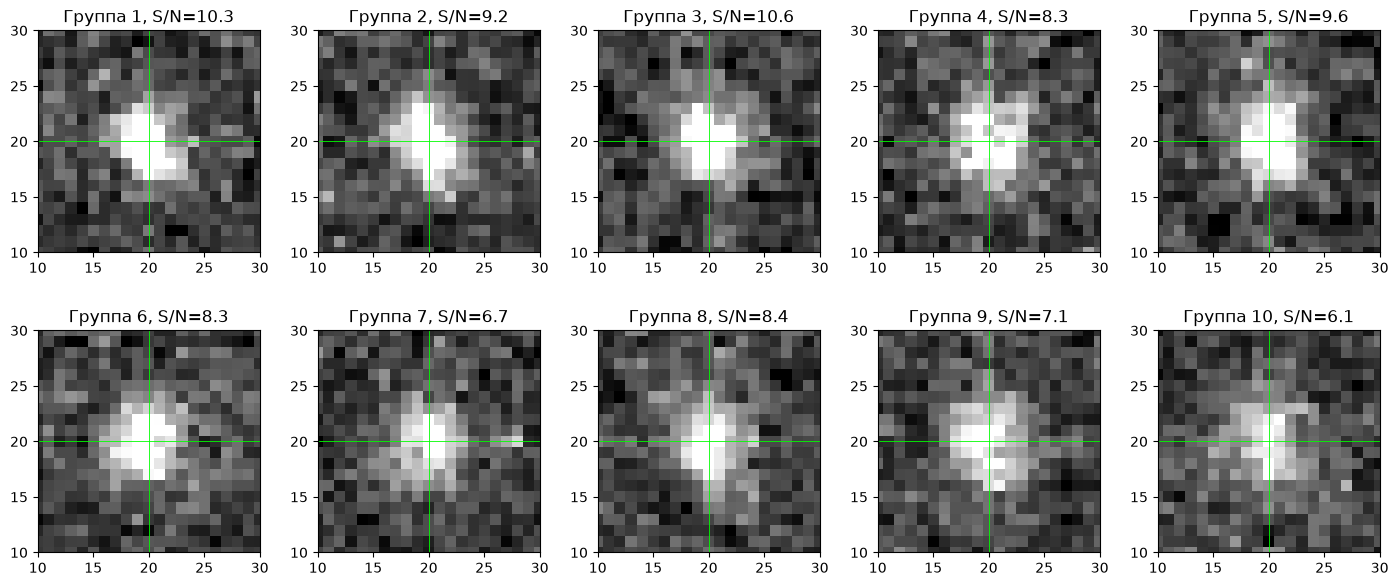

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6), constrained_layout=True)
for row, stack, ax in zip(asteroid_groups.itertuples(), group_stacks, axes.ravel()):
    _, background, noise = sigma_clipped_stats(stack, sigma=3)
    ax.imshow(stack, origin="lower", cmap="gray",
              vmin=background - 2 * noise, vmax=background + 6 * noise)
    ax.axvline(center, color="lime", linewidth=0.6)
    ax.axhline(center, color="lime", linewidth=0.6)
    ax.set_title(f"Группа {row.group}, S/N={row.snr:.1f}")
    ax.set_xlim(center - 10, center + 10)
    ax.set_ylim(center - 10, center + 10)
plt.show()

## 7. Удалите линейное движение и оцените повторяемость

Небольшой наклон `dx,dy` может остаться из-за погрешности эфемериды. Он удаляется линейной моделью времени. Разброс оставшихся точек — эмпирическая точность одного десятикадрового стека.

Медианный S/N стека: 8.4
Двумерный RMS центров после удаления линейного движения: 82.9 mas


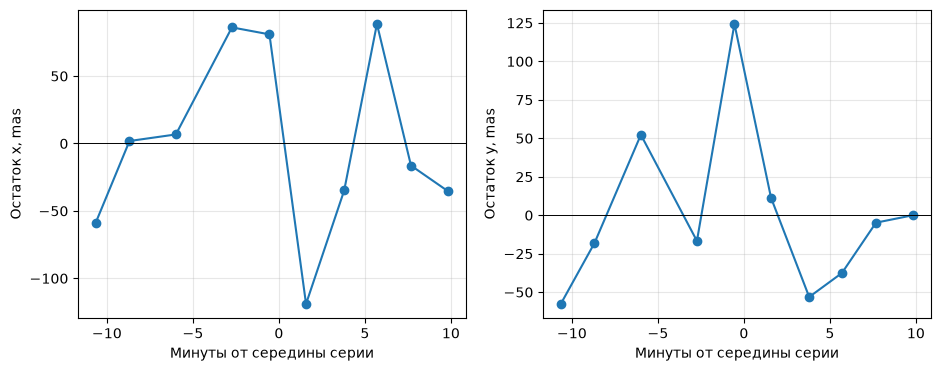

In [16]:
minutes = (asteroid_groups.middle_jd - asteroid_groups.middle_jd.mean()) * 24 * 60
line_x = np.polyfit(minutes, asteroid_groups.dx_mas, 1)
line_y = np.polyfit(minutes, asteroid_groups.dy_mas, 1)
asteroid_groups["residual_x_mas"] = asteroid_groups.dx_mas - np.polyval(line_x, minutes)
asteroid_groups["residual_y_mas"] = asteroid_groups.dy_mas - np.polyval(line_y, minutes)
empirical_rms_mas = np.sqrt(np.mean(
    asteroid_groups.residual_x_mas**2 + asteroid_groups.residual_y_mas**2
))

print(f"Медианный S/N стека: {asteroid_groups.snr.median():.1f}")
print(f"Двумерный RMS центров после удаления линейного движения: {empirical_rms_mas:.1f} mas")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
axes[0].plot(minutes, asteroid_groups.residual_x_mas, "o-")
axes[1].plot(minutes, asteroid_groups.residual_y_mas, "o-")
axes[0].set_ylabel("Остаток x, mas")
axes[1].set_ylabel("Остаток y, mas")
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_xlabel("Минуты от середины серии")
    ax.grid(alpha=0.3)
plt.show()

## Интерпретация

Формальные ошибки гауссовой подгонки учитывают шум конкретного стека, но не все систематики. Поэтому основной текущий показатель — фактический разброс независимых стеков после удаления линейного движения. Он относится к центру астероида, в отличие от RMS опорных звёзд.

## 8. Сохраните итоговые таблицы

In [17]:
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

frame_quality = frames.merge(relative_frames, on="frame").merge(gaia_frames, on="frame")
asteroid_groups.to_csv(OUTPUT_DIR / "asteroid_groups_20250903_R.csv", index=False)
star_quality.to_csv(OUTPUT_DIR / "local_star_quality_20250903_R.csv", index=False)
frame_quality.to_csv(OUTPUT_DIR / "frame_quality_20250903_R.csv", index=False)
print(f"Таблицы сохранены в {OUTPUT_DIR}")

Таблицы сохранены в /home/fanat/vlad/science/Fredschaaf/outputs
